# Parameter-Efficient Fine-Tuning of BERT using QLoRA
### Optimized for Local GPU (VS Code)

**Stack:** `transformers` · `peft` · `bitsandbytes` · `accelerate` · `wandb`

## 1. Install Dependencies

In [1]:
# Run once — restart kernel after installation
import subprocess, sys

packages = [
    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121",
    "transformers>=4.40.0",
    "datasets",
    "peft>=0.10.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.29.0",
    "scikit-learn",
    "wandb",
    "matplotlib",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkg.split(), check=True)

print("All packages installed. Restart the kernel before proceeding.")

All packages installed. Restart the kernel before proceeding.


## 2. Imports & GPU Check

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import wandb

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── GPU check ──────────────────────────────────────────────
assert torch.cuda.is_available(), (
    "CUDA not found! Make sure:\n"
    "  1. You have an NVIDIA GPU\n"
    "  2. CUDA drivers are installed (nvidia-smi works in terminal)\n"
    "  3. PyTorch was installed with the correct CUDA version above"
)

DEVICE = "cuda"
gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.version.cuda}")
print(f"GPU      : {gpu_name}")
print(f"VRAM     : {gpu_mem:.1f} GB")

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.5.1+cu121
CUDA     : 12.1
GPU      : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM     : 8.6 GB


## 3. Configuration

In [3]:
# ── Hyper-parameters ───────────────────────────────────────
MODEL_NAME   = "bert-base-uncased"
MAX_LENGTH   = 256
NUM_LABELS   = 2
NUM_EPOCHS   = 3
LEARNING_RATE = 2e-4
WEIGHT_DECAY  = 0.01

# Adjust batch size based on your VRAM
# 4 GB → 8  |  6 GB → 16  |  8+ GB → 32
BATCH_SIZE = 16 if gpu_mem >= 6 else 8
GRAD_ACCUM = 2   # effective batch = BATCH_SIZE * GRAD_ACCUM

# ── LoRA config ────────────────────────────────────────────
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.1

# ── Column names for this dataset ──────────────────────────
TEXT_COL  = "review"
LABEL_COL = "sentiment"

print(f"Batch size : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM})")
print(f"LoRA rank  : {LORA_R}")

Batch size : 16  (effective: 32)
LoRA rank  : 16


## 4. Weights & Biases

In [ ]:
import os
import wandb

os.environ["WANDB_API_KEY"] = "PASTE_YOUR_KEY_HERE"
wandb.login(key=os.environ["WANDB_API_KEY"])

wandb.init(
    project="qlora-bert-sentiment",
    name="bert-qlora-imdb-gpu",
    config={
        "model"        : MODEL_NAME,
        "dataset"      : "dipanjanS/imdb_sentiment_finetune_dataset20k",
        "quantization" : "4-bit NF4",
        "lora_r"       : LORA_R,
        "lora_alpha"   : LORA_ALPHA,
        "lora_dropout" : LORA_DROPOUT,
        "max_length"   : MAX_LENGTH,
        "batch_size"   : BATCH_SIZE,
        "grad_accum"   : GRAD_ACCUM,
        "epochs"       : NUM_EPOCHS,
        "lr"           : LEARNING_RATE,
        "gpu"          : gpu_name,
    },
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Asus\_netrc
wandb: Currently logged in as: sa-education5211 (sa-education5211-sns-college-of-allied-health-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 5. Data Preparation

In [6]:
print("Loading dataset...")
dataset = load_dataset("dipanjanS/imdb_sentiment_finetune_dataset20k")

print("Splits    :", list(dataset.keys()))
print("Columns   :", dataset["train"].column_names)
print("Train size:", len(dataset["train"]))
print("\nSample entry:")
print(dataset["train"][0])

Loading dataset...


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\datasets--dipanjanS--imdb_sentiment_finetune_dataset20k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not

Splits    : ['train', 'validation', 'test']
Columns   : ['review', 'sentiment']
Train size: 8000

Sample entry:
{'review': "One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, 

In [7]:
# ── Build label → integer mapping ──────────────────────────
raw_labels = dataset["train"][LABEL_COL]
unique_labels = sorted(set(raw_labels))
print(f"Unique label values: {unique_labels}")

if isinstance(unique_labels[0], str):
    label2id = {lbl: idx for idx, lbl in enumerate(unique_labels)}
    id2label = {idx: lbl for lbl, idx in label2id.items()}
    print(f"Mapping: {label2id}")
else:
    label2id = None
    id2label = None

# Distribution
unique, counts = np.unique(raw_labels, return_counts=True)
print(f"Label distribution: {dict(zip(unique, counts))}")

Unique label values: [0, 1]
Label distribution: {0: 3997, 1: 4003}


In [8]:
# ── Tokenizer ──────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    result = tokenizer(
        examples[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )
    if label2id is not None:
        result["label"] = [label2id[lbl] for lbl in examples[LABEL_COL]]
    else:
        result["label"] = examples[LABEL_COL]
    return result

print("Tokenizing...")
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=[TEXT_COL, LABEL_COL],
)
print("Done:", tokenized_dataset)

Tokenizing...


Map: 100%|██████████| 10000/10000 [00:01<00:00, 5197.50 examples/s]

Done: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 10000
    })
})


In [9]:
# ── Train / test split ─────────────────────────────────────
if "test" in tokenized_dataset:
    train_dataset = tokenized_dataset["train"]
    test_dataset  = tokenized_dataset["test"]
else:
    split = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=42)
    train_dataset = split["train"]
    test_dataset  = split["test"]

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format( type="torch", columns=["input_ids", "attention_mask", "label"])

print(f"Train : {len(train_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

Train : 8,000
Test  : 10,000


## 6. Model Setup — 4-bit Quantization + LoRA

In [11]:
# ── 4-bit quantization config ──────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# ── Load BERT with quantization ────────────────────────────
print(f"Loading {MODEL_NAME} with 4-bit quantization...")

# Only pass label mappings if they were built (i.e. labels were strings)
extra_label_kwargs = {}
if id2label is not None and label2id is not None:
    extra_label_kwargs = {"id2label": id2label, "label2id": label2id}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    quantization_config=bnb_config,
    device_map="auto",
    **extra_label_kwargs,
)

total_before, trainable_before = count_parameters(model)
print(f"\nBEFORE LoRA")
print(f"  Total params     : {total_before:,}")
print(f"  Trainable params : {trainable_before:,}")
print(f"  Trainable %      : {100*trainable_before/total_before:.2f}%")

Loading bert-base-uncased with 4-bit quantization...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



BEFORE LoRA
  Total params     : 66,721,538
  Trainable params : 23,875,586
  Trainable %      : 35.78%


In [12]:
# ── Prepare for k-bit training ─────────────────────────────
model = prepare_model_for_kbit_training(model)

# ── LoRA configuration ─────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["query", "value"],  # BERT attention layers
    lora_dropout=LORA_DROPOUT,
    bias="none",
    inference_mode=False,
)

model = get_peft_model(model, lora_config)

total_after, trainable_after = count_parameters(model)
print(f"AFTER LoRA (QLoRA)")
print(f"  Total params     : {total_after:,}")
print(f"  Trainable params : {trainable_after:,}")
print(f"  Trainable %      : {100*trainable_after/total_after:.2f}%")
print()
model.print_trainable_parameters()

# Log to W&B
wandb.log({
    "total_parameters"    : total_after,
    "trainable_parameters": trainable_after,
    "trainable_pct"       : 100*trainable_after/total_after,
})

AFTER LoRA (QLoRA)
  Total params     : 67,312,900
  Trainable params : 591,362
  Trainable %      : 0.88%

trainable params: 591,362 || all params: 110,075,140 || trainable%: 0.5372


## 7. Training

In [13]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1"      : f1_score(labels, preds, average="binary"),
    }

training_args = TrainingArguments(
    output_dir                = "./qlora_bert_output",
    num_train_epochs          = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate             = LEARNING_RATE,
    weight_decay              = WEIGHT_DECAY,
    warmup_ratio              = 0.1,
    lr_scheduler_type         = "cosine",
    eval_strategy             = "epoch",
    save_strategy             = "epoch",
    load_best_model_at_end    = True,
    metric_for_best_model     = "accuracy",
    greater_is_better         = True,
    logging_steps             = 50,
    report_to                 = "wandb",
    run_name                  = "bert-qlora-imdb-gpu",
    fp16                      = True,                  # mixed precision on GPU
    gradient_accumulation_steps = GRAD_ACCUM,
    optim                     = "paged_adamw_32bit",   # memory-efficient optimizer
    dataloader_num_workers    = 2,
    remove_unused_columns     = False,
    save_total_limit          = 2,
)

trainer = Trainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_dataset,
    eval_dataset     = test_dataset,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print("Trainer ready.")

Trainer ready.


In [14]:
# Log VRAM before training
torch.cuda.reset_peak_memory_stats()
vram_before = torch.cuda.memory_allocated() / 1e9
print(f"VRAM before training : {vram_before:.2f} GB")
wandb.log({"vram_before_train_gb": vram_before})

print("\nStarting training...\n")
train_result = trainer.train()

# Log VRAM after training
vram_peak  = torch.cuda.max_memory_allocated() / 1e9
vram_after = torch.cuda.memory_allocated() / 1e9
print(f"\nVRAM peak during training : {vram_peak:.2f} GB")
print(f"VRAM after training       : {vram_after:.2f} GB")
wandb.log({"vram_peak_gb": vram_peak, "vram_after_train_gb": vram_after})

print("\nTraining metrics:", train_result.metrics)

VRAM before training : 0.14 GB

Starting training...



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.288700,0.304805,0.875200,0.863547
2,0.224200,0.268345,0.895300,0.895976
3,0.195500,0.263237,0.897400,0.895943


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, 


VRAM peak during training : 0.61 GB
VRAM after training       : 0.17 GB

Training metrics: {'train_runtime': 563.6994, 'train_samples_per_second': 42.576, 'train_steps_per_second': 1.33, 'total_flos': 3179016727210752.0, 'train_loss': 0.30207025146484373, 'epoch': 3.0}


In [15]:
trainer.save_model("./qlora_bert_final")
tokenizer.save_pretrained("./qlora_bert_final")
print("Model saved to ./qlora_bert_final")

Model saved to ./qlora_bert_final


## 8. Evaluation

In [16]:
print("Evaluating on test set...")
eval_results = trainer.evaluate(test_dataset)

print("\nEvaluation Results:")
for k, v in eval_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")

wandb.log(eval_results)

Evaluating on test set...



Evaluation Results:
  eval_loss                          : 0.2632
  eval_accuracy                      : 0.8974
  eval_f1                            : 0.8959
  eval_runtime                       : 104.2304
  eval_samples_per_second            : 95.9410
  eval_steps_per_second              : 5.9960
  epoch                              : 3.0000


In [17]:
# Detailed classification report
predictions  = trainer.predict(test_dataset)
pred_labels  = np.argmax(predictions.predictions, axis=-1)
true_labels  = predictions.label_ids

label_names = list(id2label.values()) if id2label else [str(i) for i in range(NUM_LABELS)]
report = classification_report(true_labels, pred_labels, target_names=label_names)
print("Classification Report:\n")
print(report)

final_accuracy = accuracy_score(true_labels, pred_labels)
final_f1       = f1_score(true_labels, pred_labels, average="binary")
wandb.log({"test_accuracy": final_accuracy, "test_f1": final_f1})

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      5125
           1       0.89      0.91      0.90      4875

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 9. Analysis & Visualizations

In [18]:
# ── 9.1 Parameter efficiency numbers ──────────────────────
BERT_FULL_PARAMS = 109_483_778   # bert-base-uncased total

param_reduction  = (1 - trainable_after / BERT_FULL_PARAMS) * 100
# Full FT: ~16 bytes/param (fp32 weights + adam states)
# QLoRA  : ~0.5 bytes/param for frozen weights (4-bit) + full precision adapters
mem_full_ft_gb   = BERT_FULL_PARAMS * 16 / 1e9
mem_qlora_gb     = vram_peak
mem_reduction    = (1 - mem_qlora_gb / mem_full_ft_gb) * 100

print(f"{'='*55}")
print("PARAMETER & MEMORY EFFICIENCY SUMMARY")
print(f"{'='*55}")
print(f"  Full fine-tuning trainable params : {BERT_FULL_PARAMS:>12,}")
print(f"  QLoRA trainable params            : {trainable_after:>12,}")
print(f"  Trainable param reduction         : {param_reduction:>11.1f}%")
print()
print(f"  Estimated full FT memory          : {mem_full_ft_gb:>10.2f} GB")
print(f"  Actual QLoRA peak VRAM            : {mem_qlora_gb:>10.2f} GB")
print(f"  Memory reduction                  : {mem_reduction:>11.1f}%")
print(f"{'='*55}")

PARAMETER & MEMORY EFFICIENCY SUMMARY
  Full fine-tuning trainable params :  109,483,778
  QLoRA trainable params            :      591,362
  Trainable param reduction         :        99.5%

  Estimated full FT memory          :       1.75 GB
  Actual QLoRA peak VRAM            :       0.61 GB
  Memory reduction                  :        65.4%


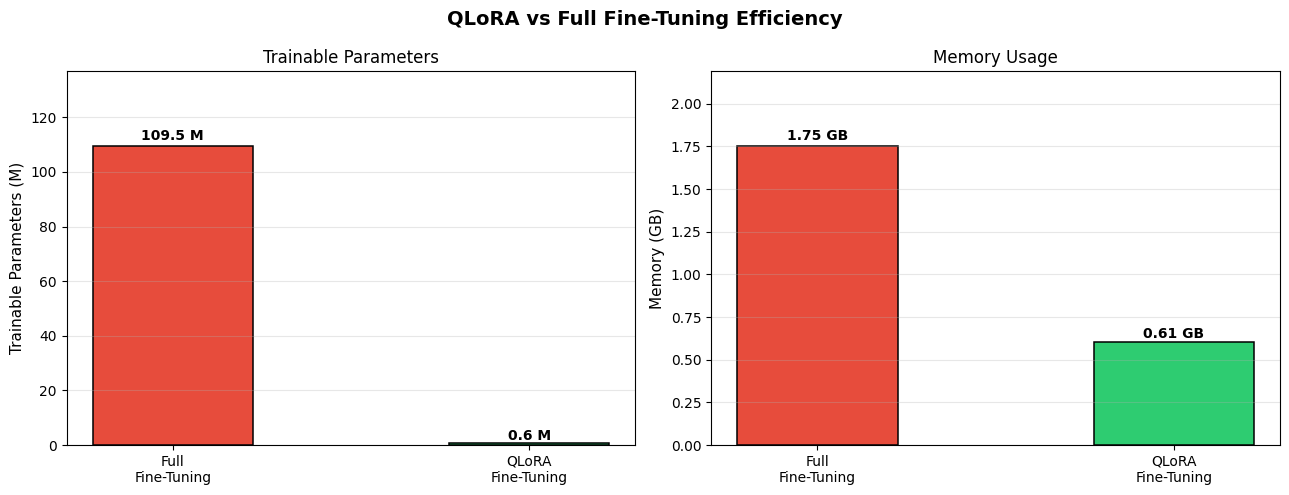

In [19]:
# ── 9.2 Parameter & memory bar charts ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("QLoRA vs Full Fine-Tuning Efficiency", fontsize=14, fontweight="bold")

colors = ["#e74c3c", "#2ecc71"]
methods = ["Full\nFine-Tuning", "QLoRA\nFine-Tuning"]

# Trainable parameters
vals_p = [BERT_FULL_PARAMS / 1e6, trainable_after / 1e6]
bars = axes[0].bar(methods, vals_p, color=colors, width=0.45, edgecolor="black", linewidth=1.1)
axes[0].set_ylabel("Trainable Parameters (M)", fontsize=11)
axes[0].set_title("Trainable Parameters", fontsize=12)
for bar, v in zip(bars, vals_p):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{v:.1f} M", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, max(vals_p) * 1.25)
axes[0].grid(axis="y", alpha=0.3)

# Memory
vals_m = [mem_full_ft_gb, mem_qlora_gb]
bars2 = axes[1].bar(methods, vals_m, color=colors, width=0.45, edgecolor="black", linewidth=1.1)
axes[1].set_ylabel("Memory (GB)", fontsize=11)
axes[1].set_title("Memory Usage", fontsize=12)
for bar, v in zip(bars2, vals_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{v:.2f} GB", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(vals_m) * 1.25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("parameter_efficiency.png", dpi=150, bbox_inches="tight")
wandb.log({"parameter_efficiency_chart": wandb.Image("parameter_efficiency.png")})
plt.show()

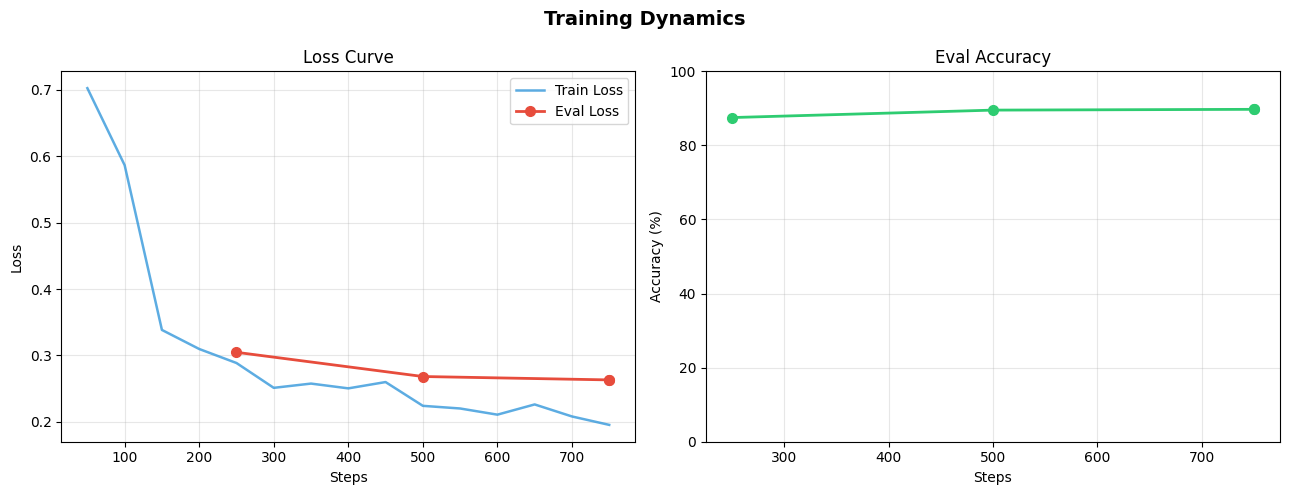

In [20]:
# ── 9.3 Training curves ────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
train_losses = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
eval_steps   = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]
eval_accs    = [e["eval_accuracy"] * 100 for e in log_history if "eval_accuracy" in e]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Training Dynamics", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(train_steps, train_losses, label="Train Loss", color="#3498db", linewidth=1.8, alpha=0.8)
axes[0].plot(eval_steps,  eval_losses,  label="Eval Loss",  color="#e74c3c",
             linewidth=2, marker="o", markersize=7)
axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(eval_steps, eval_accs, color="#2ecc71", linewidth=2, marker="o", markersize=7)
axes[1].set_xlabel("Steps"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Eval Accuracy"); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
wandb.log({"training_curves": wandb.Image("training_curves.png")})
plt.show()

## 10. Inference Demo

In [21]:
sample_texts = [
    "This movie was absolutely fantastic! The performances were stellar and the plot kept me engaged throughout.",
    "What a terrible waste of time. The acting was wooden and the story made no sense whatsoever.",
    "An average film — some good moments but overall quite forgettable.",
    "A masterpiece of modern cinema. I was moved to tears by the end.",
]

model.eval()
print(f"{'─'*65}")
for text in sample_texts:
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=MAX_LENGTH, padding=True
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probs  = torch.softmax(logits, dim=-1)
        pred   = torch.argmax(probs, dim=-1).item()
        conf   = probs[0][pred].item()

    label = id2label[pred].upper() if id2label else str(pred)
    print(f"Text  : {text[:72]}...")
    print(f"Result: {label}  (confidence: {conf:.2%})")
    print(f"{'─'*65}")

─────────────────────────────────────────────────────────────────
Text  : This movie was absolutely fantastic! The performances were stellar and t...
Result: 1  (confidence: 99.13%)
─────────────────────────────────────────────────────────────────
Text  : What a terrible waste of time. The acting was wooden and the story made ...
Result: 0  (confidence: 98.98%)
─────────────────────────────────────────────────────────────────
Text  : An average film — some good moments but overall quite forgettable....
Result: 0  (confidence: 77.22%)
─────────────────────────────────────────────────────────────────
Text  : A masterpiece of modern cinema. I was moved to tears by the end....
Result: 1  (confidence: 98.59%)
─────────────────────────────────────────────────────────────────


## 11. Final Summary

In [22]:
print("\n" + "="*60)
print("        QLORA BERT — FINAL SUMMARY")
print("="*60)
print(f"""
Model            : {MODEL_NAME}
GPU              : {gpu_name}  ({gpu_mem:.1f} GB VRAM)

Quantization     : 4-bit NF4 (double quantization)
LoRA rank        : {LORA_R}  |  alpha: {LORA_ALPHA}  |  dropout: {LORA_DROPOUT}
Target modules   : query, value

Parameter Efficiency
  Full FT params : {BERT_FULL_PARAMS:,}  (100%)
  QLoRA params   : {trainable_after:,}  ({100*trainable_after/BERT_FULL_PARAMS:.2f}%)
  Reduction      : {param_reduction:.1f}%

Memory Efficiency
  Est. Full FT   : {mem_full_ft_gb:.2f} GB
  QLoRA peak     : {mem_qlora_gb:.2f} GB
  Reduction      : {mem_reduction:.1f}%

Performance
  Test Accuracy  : {final_accuracy*100:.2f}%
  Test F1        : {final_f1:.4f}
""")
print("="*60)

wandb.summary.update({
    "final_accuracy"    : final_accuracy,
    "final_f1"          : final_f1,
    "trainable_params"  : trainable_after,
    "param_reduction_pct": param_reduction,
    "mem_reduction_pct" : mem_reduction,
    "peak_vram_gb"      : vram_peak,
})

wandb.finish()
print("\nW&B run finished. Check your dashboard for full logs.")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



        QLORA BERT — FINAL SUMMARY

Model            : bert-base-uncased
GPU              : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)

Quantization     : 4-bit NF4 (double quantization)
LoRA rank        : 16  |  alpha: 32  |  dropout: 0.1
Target modules   : query, value

Parameter Efficiency
  Full FT params : 109,483,778  (100%)
  QLoRA params   : 591,362  (0.54%)
  Reduction      : 99.5%

Memory Efficiency
  Est. Full FT   : 1.75 GB
  QLoRA peak     : 0.61 GB
  Reduction      : 65.4%

Performance
  Test Accuracy  : 89.74%
  Test F1        : 0.8959



epoch,▁
eval/accuracy,▁▇██
eval/f1,▁███
eval/loss,█▂▁▁
eval/runtime,▁▁▁█
eval/samples_per_second,██▇▁
eval/steps_per_second,██▇▁
eval_accuracy,▁
eval_f1,▁
eval_loss,▁
+22,...



W&B run finished. Check your dashboard for full logs.
